Dataset samajhna

Data kya represent karta hai?

Business / problem question kya hai?

Unsupervised mein goal kaise define karte hain jab labels nahi hote?

Data loading & basic inspection

Shape, columns, data types

Missing values, duplicates

Numerical vs categorical features

Data cleaning

Missing values ka kya karein (drop / impute / ignore)

Outliers ko pehchanna (kab remove, kab nahi)

Noise vs signal ka concept

Preprocessing

Encoding (agar categorical hua)

Scaling / normalization (kab zaroori, kab waste)

Feature transformation (log, power, etc.)

EDA (Exploratory Data Analysis)

Distribution dekhna

Feature relationships

Clustering se pehle data ka “behavior” samajhna

Algorithm selection (very important)

K-Means kab?

Hierarchical kab?

DBSCAN kab?

Gaussian Mixture kab?

High-dimensional data mein kya karein?

Model training

Hyperparameters ka role

Initialization problems

Random state ka matlab

Evaluation (unsupervised mein error kaise nikalte hain?)

Silhouette score

Inertia / WCSS

Elbow method

Davies–Bouldin index

Visual validation (plots)

Iteration

Galtiyan identify karna

Feature engineering improve karna

Algorithm change karna

Pipeline banana

End-to-end reusable pipeline

Scaling + model ek jagah

Future data pe apply karna

Final output & saving

Model save karna

Pipeline save karna

New data pe prediction / cluster assignment

In [186]:
import pandas as pd

In [187]:
df = pd.read_csv("C:/Users/mohda/Desktop/MacLrn/datasets/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [188]:
df.shape

(200, 5)

In [189]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [190]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# what is our quest whyy

## unsupervised learning

we will divided the data in 

High income – high spending

High income – low spending

Low income – high spending

Young impulsive buyers

Old conservative buyers

In [191]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [192]:
df.duplicated().sum()

np.int64(0)

In [193]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

## Scaling 
 this step is important in unsupervised learning beacause the data is not in same scale

In [194]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

## now tjhe question here is how many clusters we need to divide the data



In [195]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

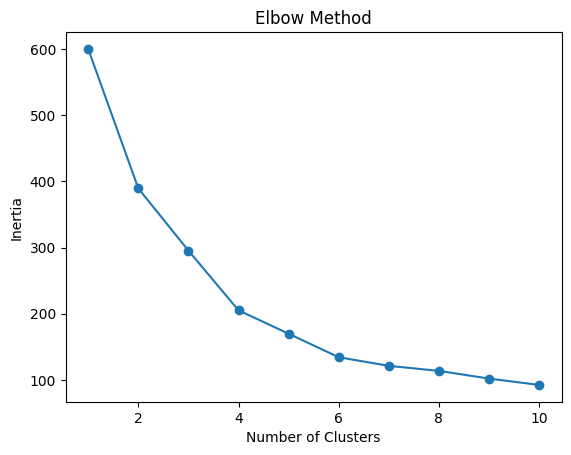

In [196]:
plt.plot(range(1,11), inertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## another method 

In [197]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)


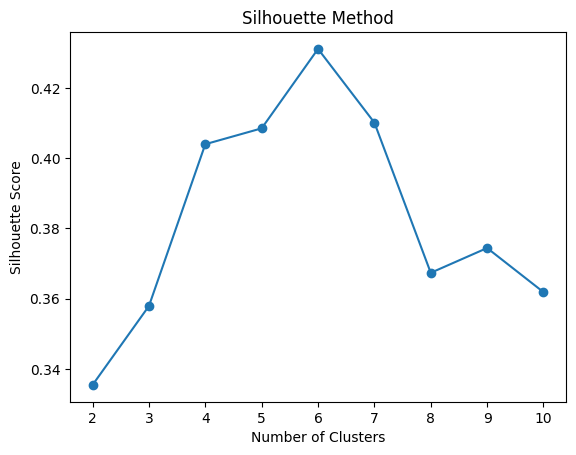

In [198]:
plt.plot(range(2,11), sil_scores,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

### k = 5 is good

In [199]:
kmeans = KMeans(n_clusters=5,random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [200]:
clusters

array([2, 2, 3, 2, 2, 2, 3, 2, 0, 2, 0, 2, 0, 2, 3, 2, 3, 2, 0, 2, 3, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 3, 2, 0, 2, 0, 2,
       0, 2, 0, 3, 3, 3, 0, 2, 3, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 0, 0, 3,
       0, 0, 3, 3, 0, 0, 0, 0, 0, 3, 0, 3, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3,
       3, 0, 0, 3, 0, 3, 3, 3, 0, 3, 0, 3, 3, 0, 0, 3, 0, 3, 0, 0, 0, 0,
       0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3, 3, 1, 1, 3, 1, 4, 1, 4, 1, 4, 1,
       3, 1, 3, 1, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 3, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [201]:
df['cluster']  = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [202]:
df.groupby('cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()


,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


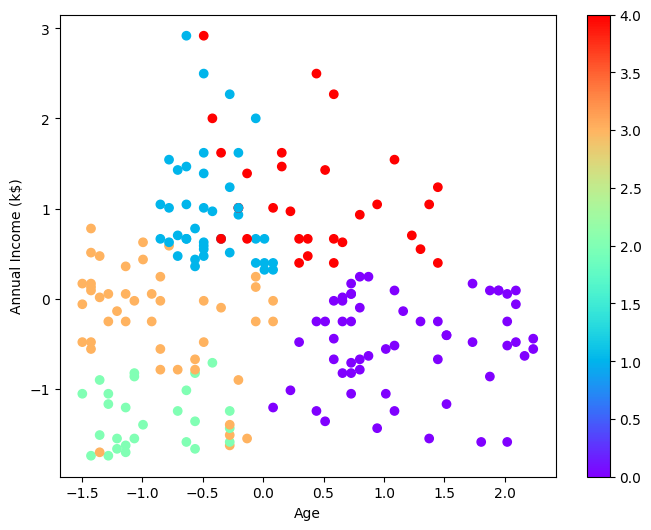

In [203]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='rainbow'
    )

plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

plt.colorbar()

plt.show()

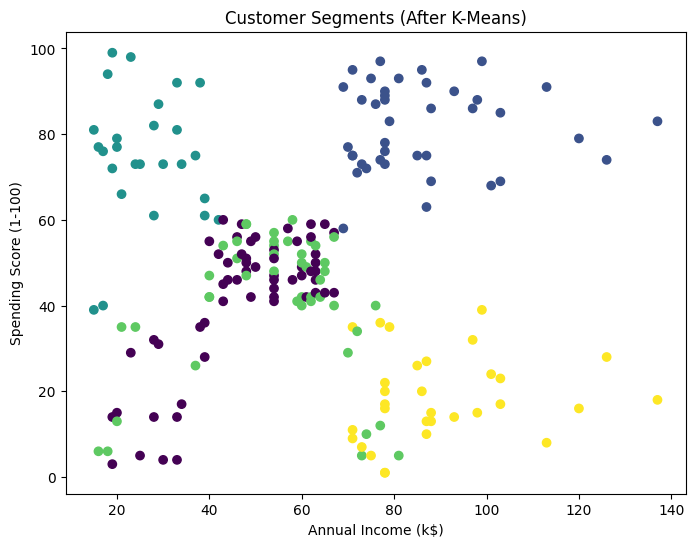

In [204]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['cluster'])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (After K-Means)")
plt.show()


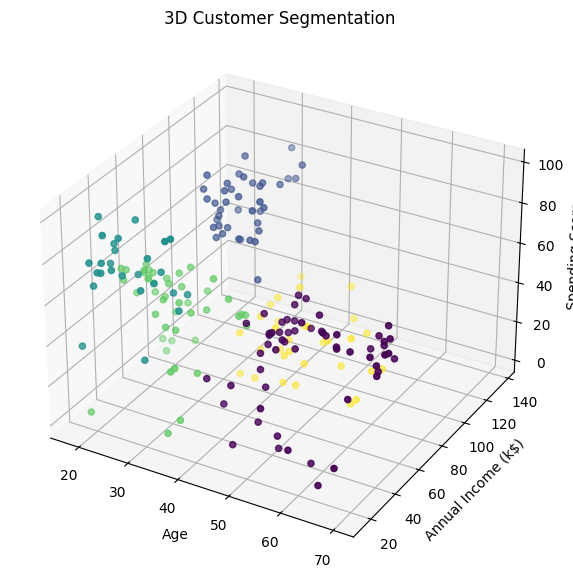

In [205]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Age'],
           df['Annual Income (k$)'],
           df['Spending Score (1-100)'],
           c=df['cluster'])

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")
ax.set_title("3D Customer Segmentation")
plt.show()


## this si it we got the answer now we will include other feartures 

In [206]:
## encoding the gender data 
df['Gender_encoded'] = df['Gender'].map({
    'Male':0,
    'Female':1
})

In [207]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Gender_encoded
0,1,Male,19,15,39,2,0
1,2,Male,21,15,81,2,0
2,3,Female,20,16,6,3,1
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,2,1


In [208]:
features_gender = df[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']
]

In [209]:
from sklearn.preprocessing import StandardScaler
scaler_g = StandardScaler()

Xg_scaled = scaler_g.fit_transform(features_gender)

In [210]:
from sklearn.cluster import KMeans

kmeans_g = KMeans(
    n_clusters=5,
    random_state=42
)
cluster_g = kmeans_g.fit_predict(Xg_scaled)

In [211]:
df['cluster_Gender'] = cluster_g

In [212]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Gender_encoded,cluster_Gender
0,1,Male,19,15,39,2,0,2
1,2,Male,21,15,81,2,0,2
2,3,Female,20,16,6,3,1,4
3,4,Female,23,16,77,2,1,4
4,5,Female,31,17,40,2,1,4


In [213]:
from sklearn.metrics import silhouette_score

score_ng = silhouette_score(X_scaled, df['cluster'])
score_g = silhouette_score(Xg_scaled, df['cluster_Gender'])

print(f"Silhouette score for non-gender data: {score_ng}")
print(f"Silhouette score for gender data: {score_g}")

Silhouette score for non-gender data: 0.40846873777345605
Silhouette score for gender data: 0.27191023466188324


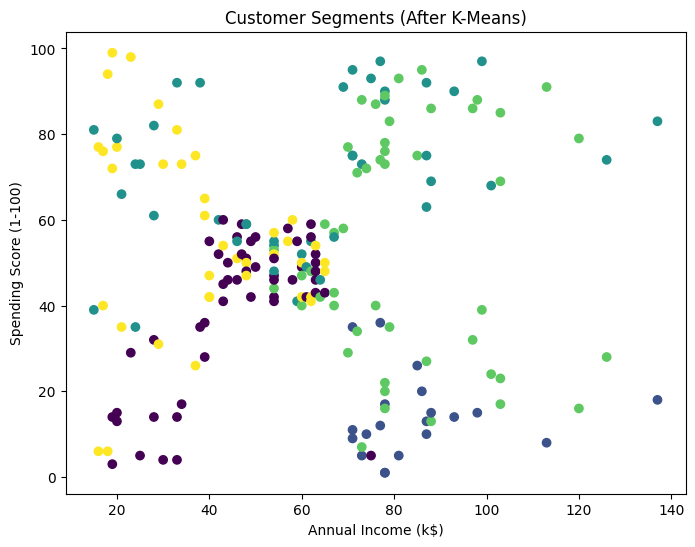

In [214]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['cluster_Gender'])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (After K-Means)")
plt.show()

## we got to know rthat the gender should be dropped will be a good choice 

In [215]:
df.groupby('cluster_Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster_Gender,,,
0,56.470588,46.098039,39.313725
1,39.500000,85.150000,14.050000
2,28.690476,60.904762,70.238095
3,37.897959,82.122449,54.448980
4,27.315789,38.842105,56.210526


## model the pipeline

In [216]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Gender_encoded,cluster_Gender
0,1,Male,19,15,39,2,0,2
1,2,Male,21,15,81,2,0,2
2,3,Female,20,16,6,3,1,4
3,4,Female,23,16,77,2,1,4
4,5,Female,31,17,40,2,1,4


In [217]:
df.drop(df[['CustomerID','Gender','cluster_Gender','Gender_encoded','cluster']], axis=1, inplace=True)

In [218]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [219]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

In [220]:
pipeline.fit(df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final 

In [221]:
df['Final_Cluster'] = pipeline.predict(df)
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Final_Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,3
3,23,16,77,2
4,31,17,40,2


In [222]:
df.groupby('Final_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Final_Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


In [223]:
new_customer = [[27,65,78]]

cluster = pipeline.predict(new_customer)
cluster

c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int32)

In [224]:
import joblib 

joblib.dump(pipeline, 'customer_segmentation_model.pkl')

['customer_segmentation_model.pkl']

In [226]:
loaded_pipline = joblib.load('customer_segmentation_model.pkl')

loaded_pipline.predict([[40,90,30]])

c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)